# Creating features
Cuando entrenamos un modelo este toma datos de las columnas, las aprende y luego trabaja para dar una respuesta. Sin embargo, no es necesario tomar las columnas completas, en algunas ocaciones. En algunas ocaciones puede haber la posibilidad de que podamos resumir dos o mas columnas en una sola columna para crear una sola columna sin tener que usar 2 o mas, incluso 3 o 4. Un ejemplo sencillo es es IMC (indice de masa corporal) que toma la altura y el peso para obtener un indice.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

accidents = pd.read_csv("data/accidents.csv")
autos = pd.read_csv("data/autos.csv")
concrete = pd.read_csv("data/concrete.csv")
customer = pd.read_csv("data/customer.csv")

## Transformacion Matematica
Relaciones entre funciones numericas son usualmente expresadas en formulas, como el IMC anteriormente mencionado. Por ejemplo, en el dataset de *Automobile* se puede describir la funcion *stroke_ratio* que es la relacion entre la eficiencia de un motor contra su performans.

In [2]:
autos["stroke_ratio"] = autos.stroke / autos.bore

autos[["stroke", "bore", "stroke_ratio"]].head()

,stroke,bore,stroke_ratio
0,2.68,3.47,0.772334
1,2.68,3.47,0.772334
2,3.47,2.68,1.294776
3,3.40,3.19,1.065831
4,3.40,3.19,1.065831


O podemos usar algo mas como la funcion de desplazamiento teneidno en cuenta el numero de cilindros.

In [3]:
autos["displacement"] = (np.pi * ((0.5 * autos.bore) ** 2) * autos.stroke * autos.num_of_cylinders)

Hacer una grafia de la funciones que estamo viendo crea una nueva distribucion que nos da una perspectiva mejor de lo que estamos viendo.

C:\Users\CDWLu\AppData\Local\Temp\ipykernel_6080\3842072694.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(accidents.WindSpeed, shade=True, ax=axs[0])
C:\Users\CDWLu\AppData\Local\Temp\ipykernel_6080\3842072694.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(accidents.LogWindSpeed, shade=True, ax=axs[1]);


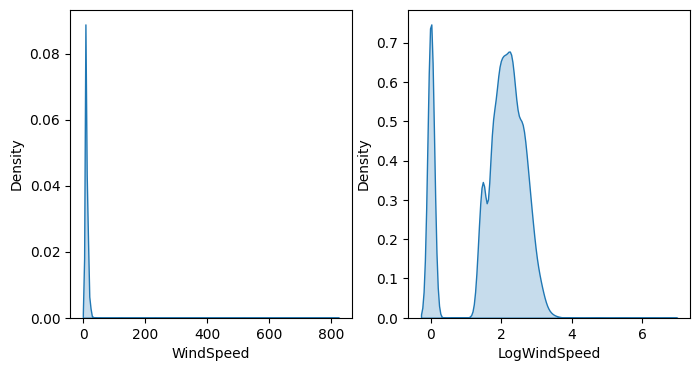

In [4]:
accidents["LogWindSpeed"] = accidents.WindSpeed.apply(np.log1p)

# graficamos la comparacion
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
sns.kdeplot(accidents.WindSpeed, shade=True, ax=axs[0])
sns.kdeplot(accidents.LogWindSpeed, shade=True, ax=axs[1]);

##### Nota
Aplicamos logaritmos cuando vemos que los registros que tenemos van desde unos muy pequeños a unos mas grandes, esto nos da una distancias entre registros muy grandes. Aplicamos logaritmos para crear unos registros nuevos pero de datos que ya tenemos, dandonos como resultados valores mas acercados entre si o mas visibles, como en el caso de WindSpeed.

## Counts
en algunas ocaciones, pueden haber datasets que nos muestren valores booleanos, presencia y ausencia. Esto es util ya que solo necesitamos porner un si o no, 0 o 1, True o False para el caso de python. Pero en algunas ocaciones, los datasets estan llenos de funciones booleanas y ver que funciones se cumplen y cuales no puede ser un poco confuso visualmente, asi que, para eso crearemos una funcion que nos diga cuantas funciones se cumplen para cierto registro.

In [5]:
roadway_features = ["Amenity", "Bump", "Crossing", "GiveWay",
    "Junction", "NoExit", "Railway", "Roundabout", "Station", "Stop",
    "TrafficCalming", "TrafficSignal"]
accidents["RoadwayFeatures"] = accidents[roadway_features].sum(axis=1)

accidents[roadway_features + ["RoadwayFeatures"]].head(10)

,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,RoadwayFeatures
0,False,False,False,False,False,False,False,False,False,False,False,False,0
1,False,False,False,False,False,False,False,False,False,False,False,False,0
2,False,False,False,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,False,False,False,0
4,False,False,False,False,False,False,False,False,False,False,False,False,0
5,False,False,False,False,True,False,False,False,False,False,False,False,1
6,False,False,False,False,False,False,False,False,False,False,False,False,0
7,False,False,True,False,False,False,False,False,False,False,False,True,2
8,False,False,True,False,False,False,False,False,False,False,False,True,2
9,False,False,False,False,False,False,False,False,False,False,False,False,0


O tambien podriamos necesitar de algunas funciones que cumplan con cierta cantidad, por ejemplo podemos taner una lista calificaciones, y aquellos que no cumplen con mayor a 8 entonces no lo contamos. Ocupando el dataset de *compression* donde tomamos datos de cementos, entonces buscamos los siguientes.

In [6]:
components = [ "Cement", "BlastFurnaceSlag", "FlyAsh", "Water",
               "Superplasticizer", "CoarseAggregate", "FineAggregate"]
concrete["Components"] = concrete[components].gt(0).sum(axis = 1)

concrete[components + ["Components"]].head(10)    

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,5
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,4


## Construyendo y Destruyendo funciones

Utilizando el dataset de constumers. Podemos hacer uso de una sola columna para dividirla en mas informacion y obtener otras columnas, es decir, podemos convertir una sola columna en 3. El metodo str nos permite utilizar la funcion `split1` para hacer eso.

In [7]:
customer[["Type", "Level"]] = (
    customer["Policy"]
    .str
    .split(" ", expand = True))

customer[["Policy", "Type", "Level"]].head(10)

,Policy,Type,Level
0,Corporate L3,Corporate,L3
1,Personal L3,Personal,L3
2,Personal L3,Personal,L3
3,Corporate L2,Corporate,L2
4,Personal L1,Personal,L1
5,Personal L3,Personal,L3
6,Corporate L3,Corporate,L3
7,Corporate L3,Corporate,L3
8,Corporate L3,Corporate,L3
9,Special L2,Special,L2


Tambie puedes unir simples funciones en funciones compuestas.

In [8]:
autos["make_and_style"] = autos["make"] + "_" + autos["body_style"]
autos[["make", "body_style", "make_and_style"]].head()

,make,body_style,make_and_style
0,alfa-romero,convertible,alfa-romero_convertible
1,alfa-romero,convertible,alfa-romero_convertible
2,alfa-romero,hatchback,alfa-romero_hatchback
3,audi,sedan,audi_sedan
4,audi,sedan,audi_sedan


## Transformando grupos
Finalmente tenemos la transformacion de grupos. Este tipo de transformacion ocupa multiples filas agrupadas en una sola categoria Basicamente tenemos que ver cual es la interaccion entre categorias y de esa forma veras como se construye una nueva columna.

In [10]:
customer["AverageIncome"] = (
    customer.groupby("State")
    ["Income"]
    .transform("mean")
)

customer[["State", "Income", "AverageIncome"]].head(10)

,State,Income,AverageIncome
0,Washington,56274,38122.733083
1,Arizona,0,37405.402231
2,Nevada,48767,38369.605442
3,California,0,37558.946667
4,Washington,43836,38122.733083
5,Oregon,62902,37557.283353
6,Oregon,55350,37557.283353
7,Arizona,0,37405.402231
8,Oregon,14072,37557.283353
9,Oregon,28812,37557.283353


La funcion `mean` esta integrado en el metodo de los dataframe, lo que significa que puede ser pasado a string con `transform`. Podemos utilizar funcoines como esta.

In [11]:
customer["StateFreq"] = (
    customer.groupby("State")
    ["State"]
    .transform("count")
    / customer.State.count()
)
customer[["State", "StateFreq"]].head(10)

,State,StateFreq
0,Washington,0.087366
1,Arizona,0.186446
2,Nevada,0.096562
3,California,0.344865
4,Washington,0.087366
5,Oregon,0.284760
6,Oregon,0.284760
7,Arizona,0.186446
8,Oregon,0.284760
9,Oregon,0.284760


Supongamos que tienes dos df, uno para entrenar y otro para validar.

In [15]:
df_train = customer.sample(frac = 0.5)
df_valid = customer.drop(df_train.index)

# cremos el monto promedio por reclamo
df_train["AverageClaim"] = df_train.groupby("Coverage")["ClaimAmount"].transform("mean")

# mesclamos los valores dentro del conjunto de validacion
df_valid = df_valid.merge(
    df_train[['Coverage', 'AverageClaim']].drop_duplicates(), 
    on = "Coverage", 
    how = "left"
)

df_valid[["Coverage", "AverageClaim"]].head(10)

,Coverage,AverageClaim
0,Basic,378.635045
1,Basic,378.635045
2,Extended,481.471719
3,Basic,378.635045
4,Premium,671.451340
5,Basic,378.635045
6,Basic,378.635045
7,Basic,378.635045
8,Basic,378.635045
9,Basic,378.635045
